# Fuel Efficiency Prediction (Auto MPG) — Exploratory Data Analysis

We explore the **UCI Auto MPG** dataset (cars from 1970–1982) to understand which engine and chassis attributes predict fuel efficiency.

**Dataset**: 398 cars, 7 numeric/categorical features (`cylinders`, `displacement`, `horsepower`, `weight`, `acceleration`, `model_year`, `origin`) and the regression target `mpg` (miles per gallon).

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

## 2. Load Data

In [2]:
df = pd.read_csv("data/auto_mpg.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


## 3. Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


In [4]:
df.describe(include='all').round(2)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
count,398.00,398.00,398.00,392.00,398.00,398.00,398.00,398.00,398
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,305
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ford pinto
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
mean,23.51,5.45,193.43,104.47,2970.42,15.57,76.01,1.57,NaN
std,7.82,1.70,104.27,38.49,846.84,2.76,3.70,0.80,NaN
min,9.00,3.00,68.00,46.00,1613.00,8.00,70.00,1.00,NaN
25%,17.50,4.00,104.25,75.00,2223.75,13.82,73.00,1.00,NaN
50%,23.00,4.00,148.50,93.50,2803.50,15.50,76.00,1.00,NaN
75%,29.00,8.00,262.00,126.00,3608.00,17.18,79.00,2.00,NaN


In [5]:
print(f"Duplicate rows : {df.duplicated().sum()}")
print(f"Unique car names: {df['car_name'].nunique()}")

Duplicate rows : 0
Unique car names: 305


## 4. Missing / Invalid Values

In [6]:
missing = df.isnull().sum()
print(missing[missing>0])

horsepower    6
dtype: int64


## 5. Target Variable Distribution

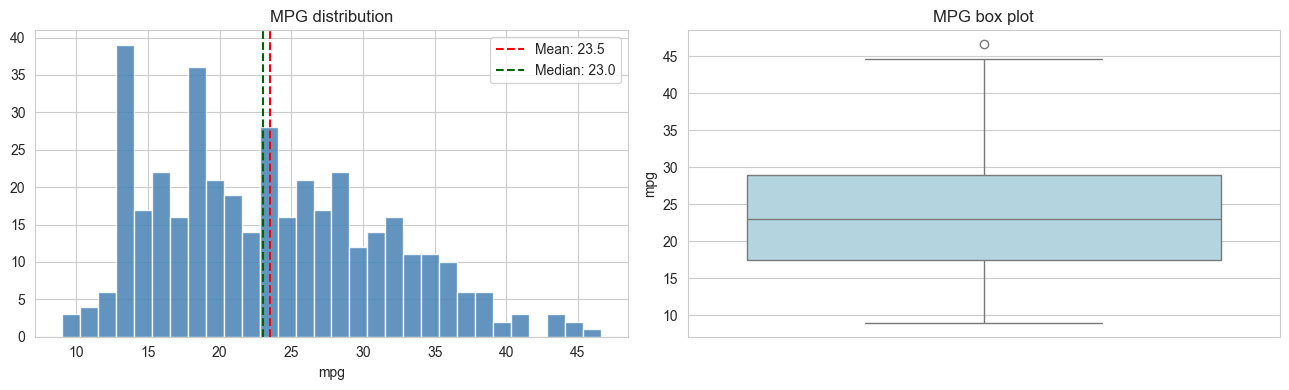

MPG skewness: 0.46


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df["mpg"], bins=30, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(df["mpg"].mean(), color="red", linestyle="--", label=f"Mean: {df['mpg'].mean():.1f}")
axes[0].axvline(df["mpg"].median(), color="darkgreen", linestyle="--", label=f"Median: {df['mpg'].median():.1f}")
axes[0].set_title("MPG distribution"); axes[0].set_xlabel("mpg"); axes[0].legend()

sns.boxplot(y=df["mpg"], ax=axes[1], color="lightblue")
axes[1].set_title("MPG box plot")
plt.tight_layout(); plt.show()
print(f"MPG skewness: {df['mpg'].skew():.2f}")

## 6. Univariate — Numeric Features

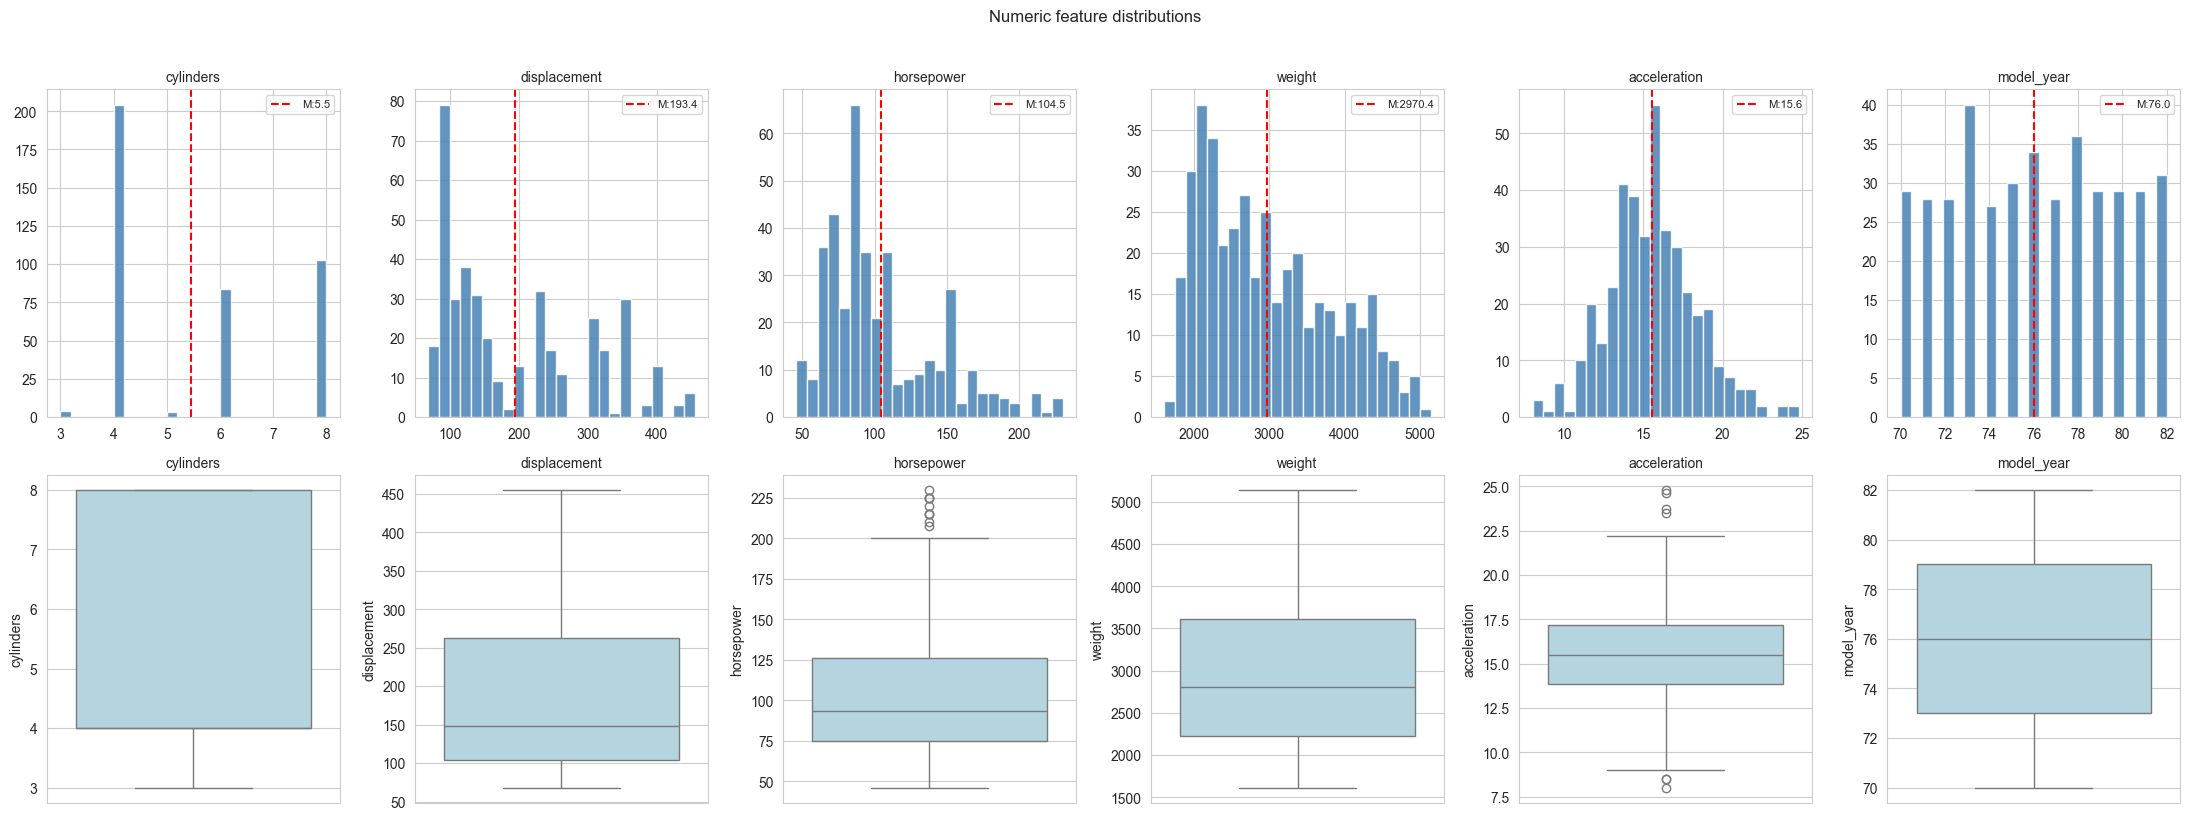

In [8]:
num_features = ["cylinders","displacement","horsepower","weight","acceleration","model_year"]
fig, axes = plt.subplots(2, 6, figsize=(22, 8))
for i, col in enumerate(num_features):
    df[col].dropna().hist(bins=25, color="steelblue", edgecolor="white", alpha=0.85, ax=axes[0,i])
    axes[0,i].axvline(df[col].mean(), color="red", linestyle="--",
                      label=f"M:{df[col].mean():.1f}")
    axes[0,i].set_title(col, fontsize=10); axes[0,i].legend(fontsize=8)
    sns.boxplot(y=df[col], ax=axes[1,i], color="lightblue")
    axes[1,i].set_title(col, fontsize=10)
plt.suptitle("Numeric feature distributions", y=1.02)
plt.tight_layout(); plt.show()

## 7. Univariate — Origin (region of manufacture)

/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_53185/2316689740.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="origin_label", y="mpg", data=df_o, palette="Set2", ax=axes[1])


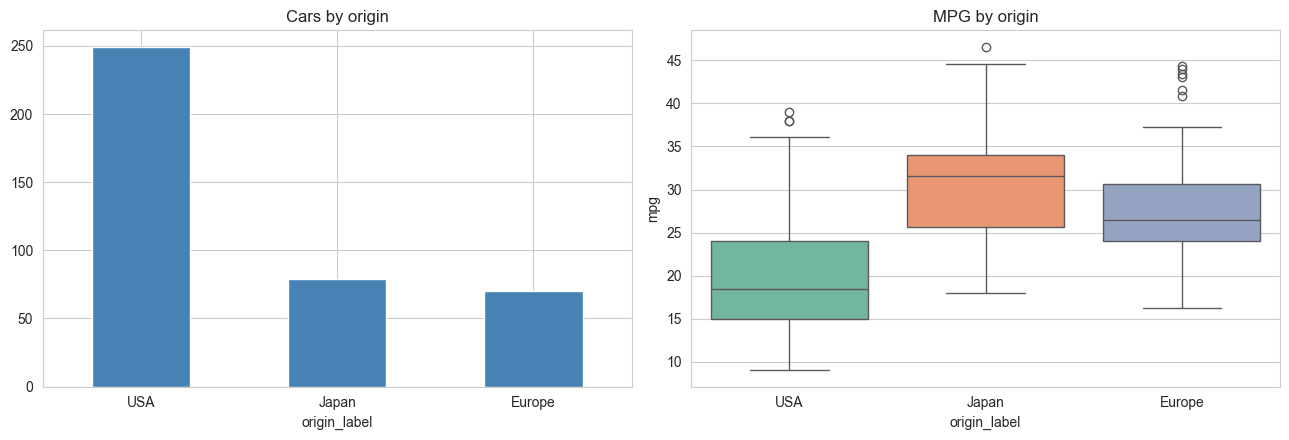

               mean  median  count
origin_label                      
Europe        27.89    26.5     70
Japan         30.45    31.6     79
USA           20.08    18.5    249


In [9]:
origin_map = {1:"USA", 2:"Europe", 3:"Japan"}
df_o = df.copy()
df_o["origin_label"] = df_o["origin"].map(origin_map)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
df_o["origin_label"].value_counts().plot(kind="bar", color="steelblue", ax=axes[0])
axes[0].set_title("Cars by origin")
axes[0].tick_params(axis="x", rotation=0)
sns.boxplot(x="origin_label", y="mpg", data=df_o, palette="Set2", ax=axes[1])
axes[1].set_title("MPG by origin")
plt.tight_layout(); plt.show()
print(df_o.groupby("origin_label")["mpg"].agg(["mean","median","count"]).round(2))

## 8. Bivariate — Numeric Features vs MPG

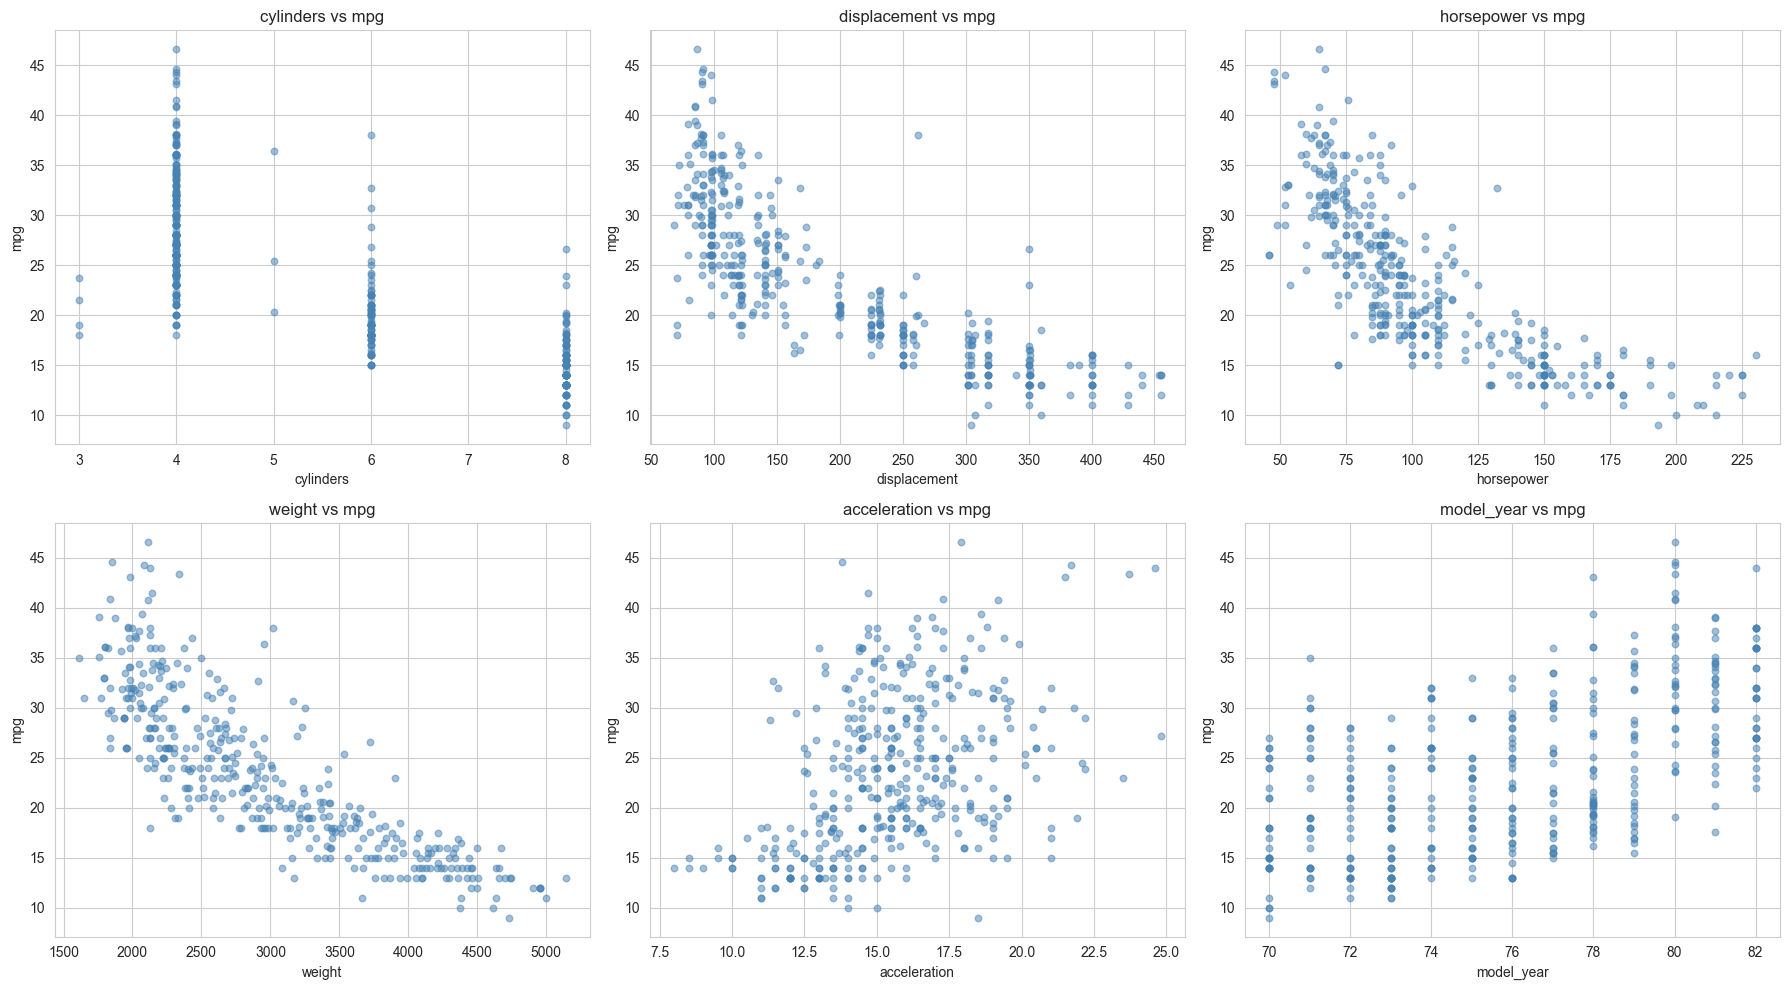

Pearson correlations with mpg:
cylinders      -0.775
displacement   -0.804
horsepower     -0.778
weight         -0.832
acceleration    0.420
model_year      0.579
Name: mpg, dtype: float64


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(num_features):
    axes[i].scatter(df[col], df["mpg"], alpha=0.5, color="steelblue", s=22)
    axes[i].set_xlabel(col); axes[i].set_ylabel("mpg")
    axes[i].set_title(f"{col} vs mpg")
plt.tight_layout(); plt.show()
print("Pearson correlations with mpg:")
print(df[num_features + ["mpg"]].corr()["mpg"].drop("mpg").round(3))

## 9. Cylinders × Origin Interaction

US cars dominate the V8 segment; Japanese and European cars are mostly 4-cylinder.

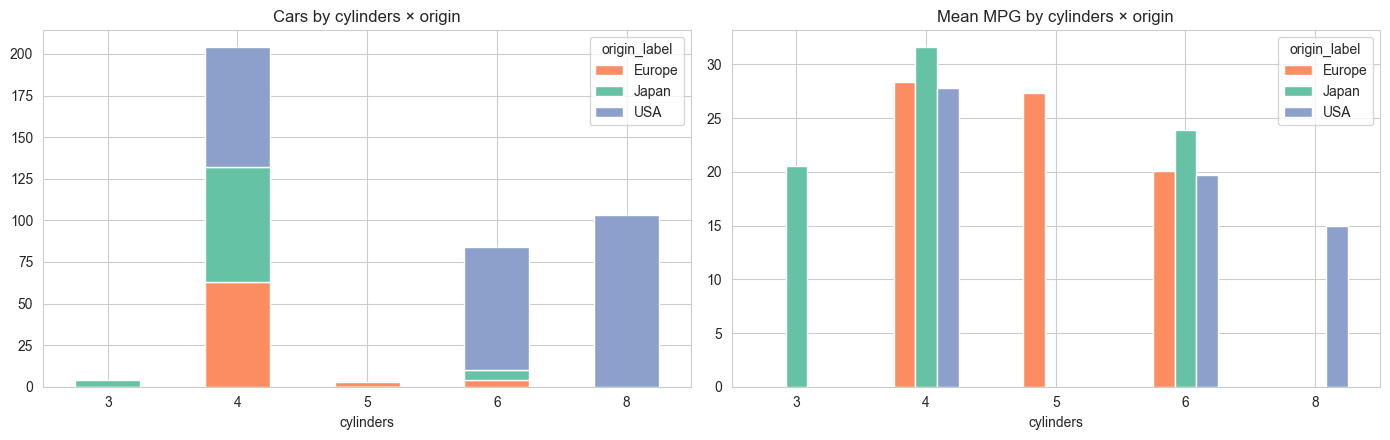

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ct = pd.crosstab(df["cylinders"], df_o["origin_label"])
ct.plot(kind="bar", stacked=True, color=["#fc8d62","#66c2a5","#8da0cb"], ax=axes[0])
axes[0].set_title("Cars by cylinders × origin")
axes[0].tick_params(axis="x", rotation=0)

mpg_by = df_o.groupby(["cylinders","origin_label"])["mpg"].mean().unstack()
mpg_by.plot(kind="bar", color=["#fc8d62","#66c2a5","#8da0cb"], ax=axes[1])
axes[1].set_title("Mean MPG by cylinders × origin")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

## 10. Model-Year Trend

During the 1970s–80s the US went through a major fuel economy push. We expect MPG to climb over time.

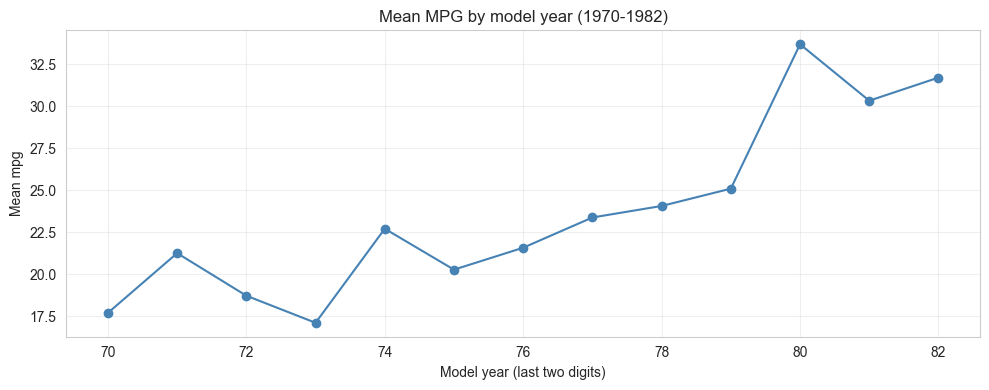

Mean MPG per year:
model_year
70    17.69
71    21.25
72    18.71
73    17.10
74    22.70
75    20.27
76    21.57
77    23.38
78    24.06
79    25.09
80    33.70
81    30.33
82    31.71
Name: mpg, dtype: float64


In [12]:
yearly = df.groupby("model_year")["mpg"].mean()
plt.figure(figsize=(10, 4))
yearly.plot(marker="o", color="steelblue")
plt.title("Mean MPG by model year (1970-1982)")
plt.ylabel("Mean mpg"); plt.xlabel("Model year (last two digits)")
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("Mean MPG per year:")
print(yearly.round(2))

## 11. Correlation Analysis

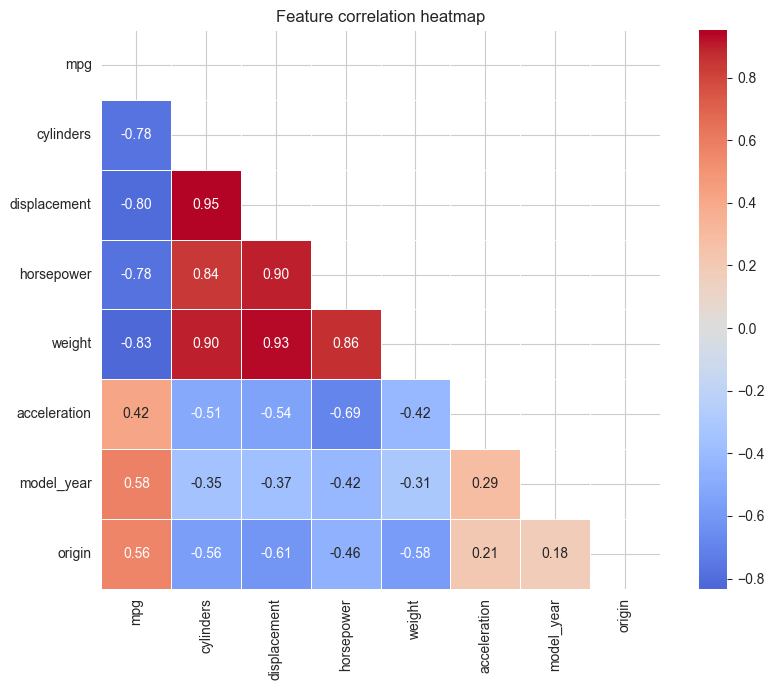

In [13]:
plt.figure(figsize=(9, 7))
df_num = df.drop(columns=["car_name"]).copy()
corr = df_num.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5)
plt.title("Feature correlation heatmap")
plt.tight_layout(); plt.show()

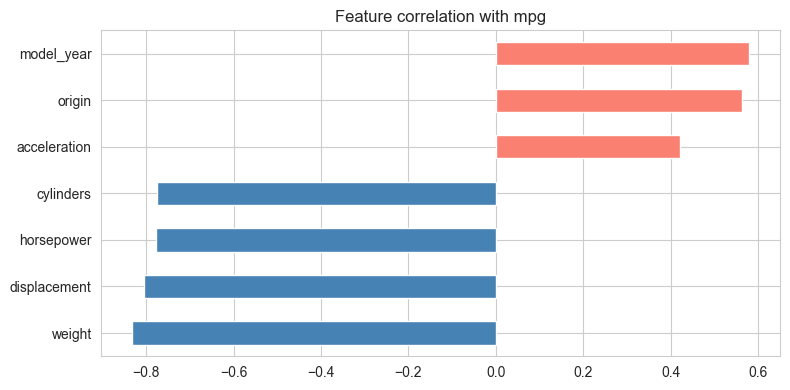

model_year      0.579
origin          0.563
acceleration    0.420
cylinders      -0.775
horsepower     -0.778
displacement   -0.804
weight         -0.832
Name: mpg, dtype: float64


In [14]:
target_corr = df_num.corr(numeric_only=True)["mpg"].drop("mpg").sort_values(ascending=False)
plt.figure(figsize=(8, 4))
target_corr.plot(kind="barh", color=["salmon" if x > 0 else "steelblue" for x in target_corr])
plt.title("Feature correlation with mpg")
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()
print(target_corr.round(3))

## 12. Pair Plot — Top Predictors

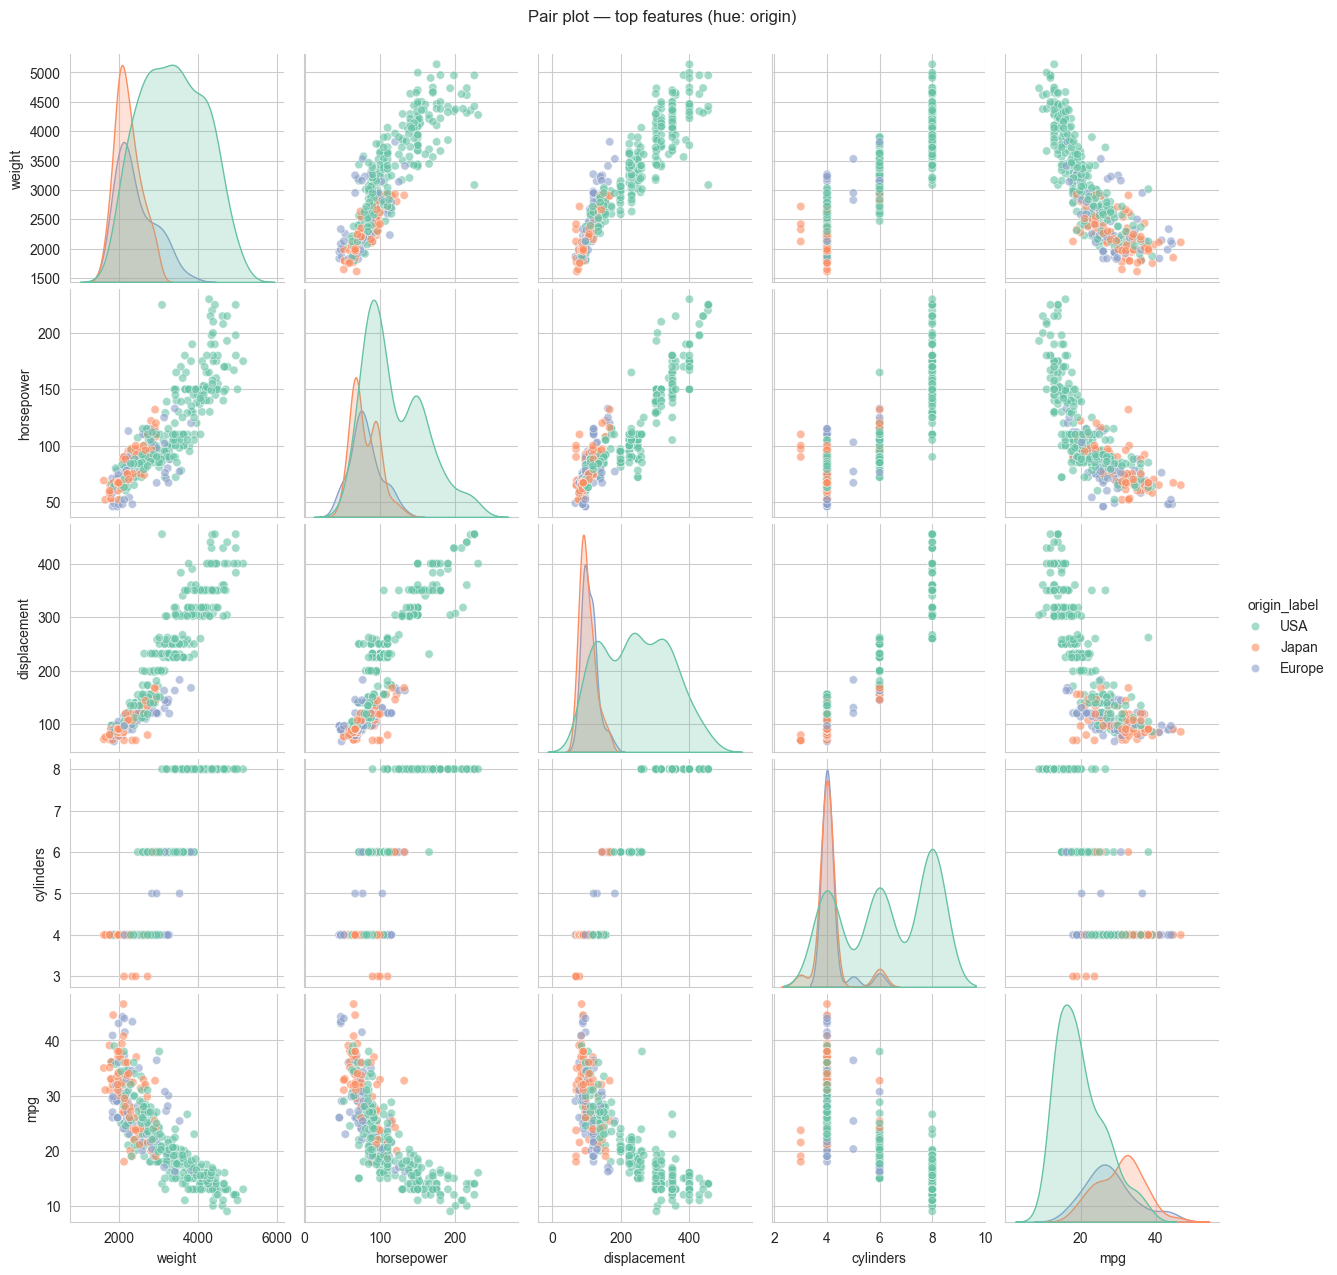

In [15]:
sns.pairplot(df_o[["weight","horsepower","displacement","cylinders","mpg","origin_label"]],
             hue="origin_label", palette="Set2", diag_kind="kde",
             plot_kws={"alpha": 0.6})
plt.suptitle("Pair plot — top features (hue: origin)", y=1.02)
plt.show()

## 13. Key EDA Findings

| # | Finding |
|---|--------|
| 1 | **Weight is the strongest single predictor** of MPG (r ≈ −0.83) — heavy cars use more fuel |
| 2 | **Cylinders, displacement, and horsepower** are heavily intercorrelated (each r > 0.9 with weight) — multicollinearity is severe |
| 3 | **Model year matters a lot**: mean MPG rises from ~17 in 1970 to ~31 in 1982 — fuel-economy regulation in action |
| 4 | **Japanese cars are the most efficient** (mean ~30 MPG), then European (~28), then US (~20) — driven mostly by smaller engines |
| 5 | **6 missing horsepower values** (1.5%) — a small impute is enough; median works fine |
| 6 | **Target is mildly right-skewed** but not enough to need a log transform |
| 7 | **`car_name` is a free-text identifier** that effectively encodes make/model — drop it before modeling to avoid leakage |